# Opgavesæt 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Opgave 3.1

Lad

$$
s = 2, \; 
t = 3, \; 
A = \begin{bmatrix}
2 & 1 & -1 \\
0 & 2 & 5
\end{bmatrix}, \;
B = \begin{bmatrix}
1 & -1 & 0 \\
0 & 1 & -1
\end{bmatrix}
$$

Hvilke af de følgende udtryk er tilladt? For dem, der er tilladt, beregn svaret (python kan godt bruges); for dem, der ikke er tilladt, forklar hvorfor.

In [2]:
s = 2
t = 3
A = np.array([  [2.0, 1.0, -1.0],
                [0.0, 2.0, 5.0]])
B = np.array([  [1.0, -1.0, 0.0],
                [0.0, 1.0, -1.0]])

### (a) sB

In [3]:
s * B

array([[ 2., -2.,  0.],
       [ 0.,  2., -2.]])

### (b) A + tB

In [4]:
A + t * B

array([[ 5., -2., -1.],
       [ 0.,  5.,  2.]])

### (c) $A^T$

In [5]:
A.T

array([[ 2.,  0.],
       [ 1.,  2.],
       [-1.,  5.]])

### (d) $A^{T} + sB$

### (e) $sA^{T} - tB^{T}$

In [6]:
s * A.T - t * B.T

array([[ 1.,  0.],
       [ 5.,  1.],
       [-2., 13.]])

### (f) $AB$

### (g) $BA$

### (h) $A^{T} B$

In [7]:
A.T @ B

array([[ 2., -2.,  0.],
       [ 1.,  1., -2.],
       [-1.,  6., -5.]])

### (i) $sAB^{T}$

In [8]:
s * A @ B.T

array([[ 2.,  4.],
       [-4., -6.]])

### (j) $BA^{T}Bt$

In [9]:
B @ A.T @ B * t

array([[  3.,  -9.,   6.],
       [  6., -15.,   9.]])

## Opgave 3.2

Lad $R_{0}$ og $R_{1}$ være rotationsmatricerne fra eksempel 4.8 i Notesæt 4, taget med $c=0.8$, $s=0.6$. Beregn matrixprodukterne
$$
R_{0} R_{1} \; \text{ og } \; R_{1} R_{0}
$$
og bekræft at resultaterne er forskellige. Hvad betyder dette for en opgraderet version af robotarmen fra Afleveringsopgave 1 hvor ledende kan bøje sig i tre dimensioner?

In [10]:
c = 0.8
s = 0.6

R0 = np.array([ [1.0, 0.0, 0.0],
                [0.0, c, -s],
                [0.0, s, c]])

R1 = np.array([ [c, 0.0, -s],
                [0.0, 1.0, 0.0],
                [s, 0.0, c]])

In [11]:
print("R0 R1\n", R0 @ R1)
print()
print("R1 R0\n",R1 @ R0)

R0 R1
 [[ 0.8   0.   -0.6 ]
 [-0.36  0.8  -0.48]
 [ 0.48  0.6   0.64]]

R1 R0
 [[ 0.8  -0.36 -0.48]
 [ 0.    0.8  -0.6 ]
 [ 0.6   0.48  0.64]]


Det at resultaterne er forskellige betyder at produktet af rotationsmatricerne ikke er kommutativt, og at man derfor skal være opmærksom på rækkefølgen.

## Opgave 3.3

11 computere $C_{0}, \dots, C_{10}$ er forbbundet i netværket som nedenfor

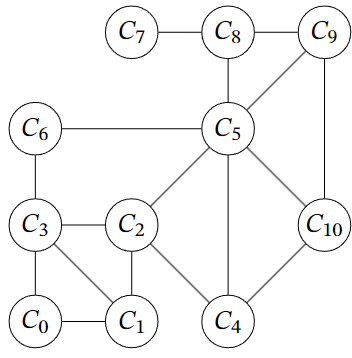

### (a)

Dan i python nabomatricen $A = (a_{ij}) \in \mathbb{R}^{11 \times 11}$, som har $a_{ij} = 1$ hvis $C_{i}$ er direkte forbundet til $C_{j}$ og har $a_{ij} = 0$ ellers. Bemærk $C_{i}$ er ikke forbundet til sig selv. Det kan hjælpe at bruge ```
```python
np.zeros(...)
``` 
og operationer som
```python
a[0, [1,3]] = 1.
```


In [2]:
A = np.zeros((11, 11))

A[0, [1, 3]] = 1
A[1, [0, 2, 3]] = 1
A[2, [1, 3, 4, 5]] = 1
A[3, [0, 1, 2, 6]] = 1
A[4, [2, 5, 10]] = 1
A[5, [2, 4, 6, 8, 9, 10]] = 1
A[6, [3, 5]] = 1
A[7, [8]] = 1
A[8, [5, 7, 9]] = 1
A[9, [5, 8, 10]] = 1
A[10, [4, 5, 9]] = 1

print(A)

[[0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0.]
 [1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1.]
 [0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1.]
 [0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0.]]


In [5]:
print(A@A)

[[2. 1. 2. 1. 0. 0. 1. 0. 0. 0. 0.]
 [1. 3. 1. 2. 1. 1. 1. 0. 0. 0. 0.]
 [2. 1. 4. 1. 1. 1. 2. 0. 1. 1. 2.]
 [1. 2. 1. 4. 1. 2. 0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 3. 2. 1. 0. 1. 2. 1.]
 [0. 1. 1. 2. 2. 6. 0. 1. 1. 2. 2.]
 [1. 1. 2. 0. 1. 0. 2. 0. 1. 1. 1.]
 [0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0.]
 [0. 0. 1. 0. 1. 1. 1. 0. 3. 1. 2.]
 [0. 0. 1. 0. 2. 2. 1. 1. 1. 3. 1.]
 [0. 0. 2. 0. 1. 2. 1. 0. 2. 1. 3.]]


In [6]:
print(A.T)

[[0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0.]
 [1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1.]
 [0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1.]
 [0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0.]]


### (b)

Tjek at $A^{T} = A$. Lad $A^{k}$ være matrixproduktet af A med sig selv $k$-gange:
$$
A^{k} = A A \dots A
$$
Beregn $A^{2} = A, A^{3} \text{ og } A^{5}$ i python. Det vides at den $(i,j)$-indgang i $A^{k}$ kan betragtes som antallet af stier af længde $k$ i netværket fra $C_{i}$ til $C_{j}$. Brug dette og de beregnede matricer til at svare på følgende spørgsmål, der kan eventuelt bruges funktionerne
```python
np.count_nonzero()
np.argwhere()
```

In [13]:
print(np.count_nonzero(A.T - A))

A2 = A@A
print(np.count_nonzero(A2 - A))

A3 = A2@A
print(np.count_nonzero(A2 - A3))

A5 = A3@A@A
print(np.count_nonzero(A2 - A5))

0
65
92
121


### (c)

Hvor mange computer har en sti af længde 2 til $C_{5}$?

In [14]:
computer = 9
path_amount = np.count_nonzero(A2[computer])

print(f"Der er {path_amount} stier af længden 2 til C{computer}")

Der er 8 stier af længden 2 til C9


### (d)

Hvor mange computer har en sti af længde 2 til $C_{7}$?

In [15]:
computer = 7
path_amount = np.count_nonzero(A2[computer])

print(f"Der er {path_amount} stier af længden 2 til C{computer}")

Der er 3 stier af længden 2 til C7


### (e)

Hvilke computer kan ikke nås fra $C_{9}$ med en sti af længde højst 3?

In [28]:
computer = 9
path_1 = np.argwhere(A[computer] != 0)
path_2 = np.argwhere(A2[computer] != 0)
path_3 = np.argwhere(A3[computer] != 0)

for i in range(11):
    if i not in path_1 and i not in path_2 and i not in path_3:
        print(f"C{i} kan ikke nås fra C{computer}")

C0 kan ikke nås fra C9


### (f)

Er der nogle computer, som ikke kan nås fra $C_{0}$ med en sti af længde 4?
Kan du forklare hvorfor $A^{k}$ tæller stier af længde $k$ på denne måde?

In [30]:
computer = 0
A4 = A3 @ A
path = np.argwhere(A4[computer] != 0)

for i in range(11):
    if i not in path:
        print(f"C{i} kan ikke nås fra C{computer}")

C7 kan ikke nås fra C0


Det kan ses som at første matrix i hvert multiplikations led viser hvor mange skridt det tager at nå til den computer. Den anden matrix viser derefter hvor man kan komme hen efter at have nået til den computer. Jo flere gange man ganger matricerne sammen jo flere skridt svare det da bare til.

## Opgave 3.4

Betragt algoritmen $\color{#9c864c}{\text{Matrixprodukt}(A,B)}$ fra Notesæt 5, §5.1 for  
matrixproduktet af $A \in \mathbb{R}^{m \times n}$, $B \in \mathbb{R}^{n \times r}$. Vi kan skrive række-søjleproduktet ud og flytte nulstilling af resultatmatricen $C$ til begyndelsen, til at få den følgende:

```pseudo
Matrixprodukt-II(A,B)
𝐶 = 0𝑚×𝑟
for 𝑖 ∈ {0,1,...,𝑚 −1}:  
	for 𝑗 ∈ {0,1,...,𝑟 −1}:  
		for 𝑘 ∈ {0,1,...,𝑛 −1}:  
			𝑐𝑖𝑗 = 𝑐𝑖𝑗 +𝑎𝑖𝑘 *𝑏𝑘𝑗  
return 𝐶
```

Dette har den fordel, at linjer 2, 3, 4 kan nu ombyttes, som vi har lyst. På denne måde får vi i alt 6 forskellige algoritmer. Tre af disse algoritmer svarer til de tre forskellige præsentationer af matrixproduktet i Notesæt 4, ligninger (4.1), (4.2) og (4.3): hvilke tre? Kan du give tilsvarende fortolkninger for nogle af de resterende tre algoritmer?